In [1]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [2]:
def nome (stringa):
    
    stringa_nuova = stringa.replace(f'./Data/Results_','').replace('.csv','')
    return stringa_nuova

In [24]:
input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir(f'./Data'))]
data = {}

for input_file in input_files:
    letti = pd.read_csv(input_file)
    data[nome(input_file)] = {}


    for key in letti.keys():
        colonna = letti[key]
        try:
            # prova a convertirla in float
            data[nome(input_file)][key] = colonna.astype(float).to_numpy()
        except ValueError:
            # se non ci riesce, tieni le stringhe
            data[nome(input_file)][key] = colonna.astype(str).to_list()

# 1. Polarizzatori

Viene 
$$
\sum_{i=1}^{N} \left( \frac{y_i - \left(a x_i^2 + b x_i + c\right)}{\sigma_{y_i}} \right)^2
$$

Fit polarizzatore 1
	a = -2610.71073 ± 0.00004 
	b = -15892.408 ± 0.001 
	c = 18598595.017 ± 0.009 

Fit polarizzatore 2
	a = -2498.72877 ± 0.00006 
	b = 22820.185 ± 0.002 
	c = 16427731.88 ± 0.06 

Fit lambda_mezzi
	a = -9761.8970 ± 0.0001 
	b = 1046232.07 ± 0.01 
	c = -11839756.6 ± 0.3 

Fit lambda_quarti
	a = -52.50365 ± 0.00003 
	b = 2568.306 ± 0.005 
	c = 11379656.3 ± 0.2 



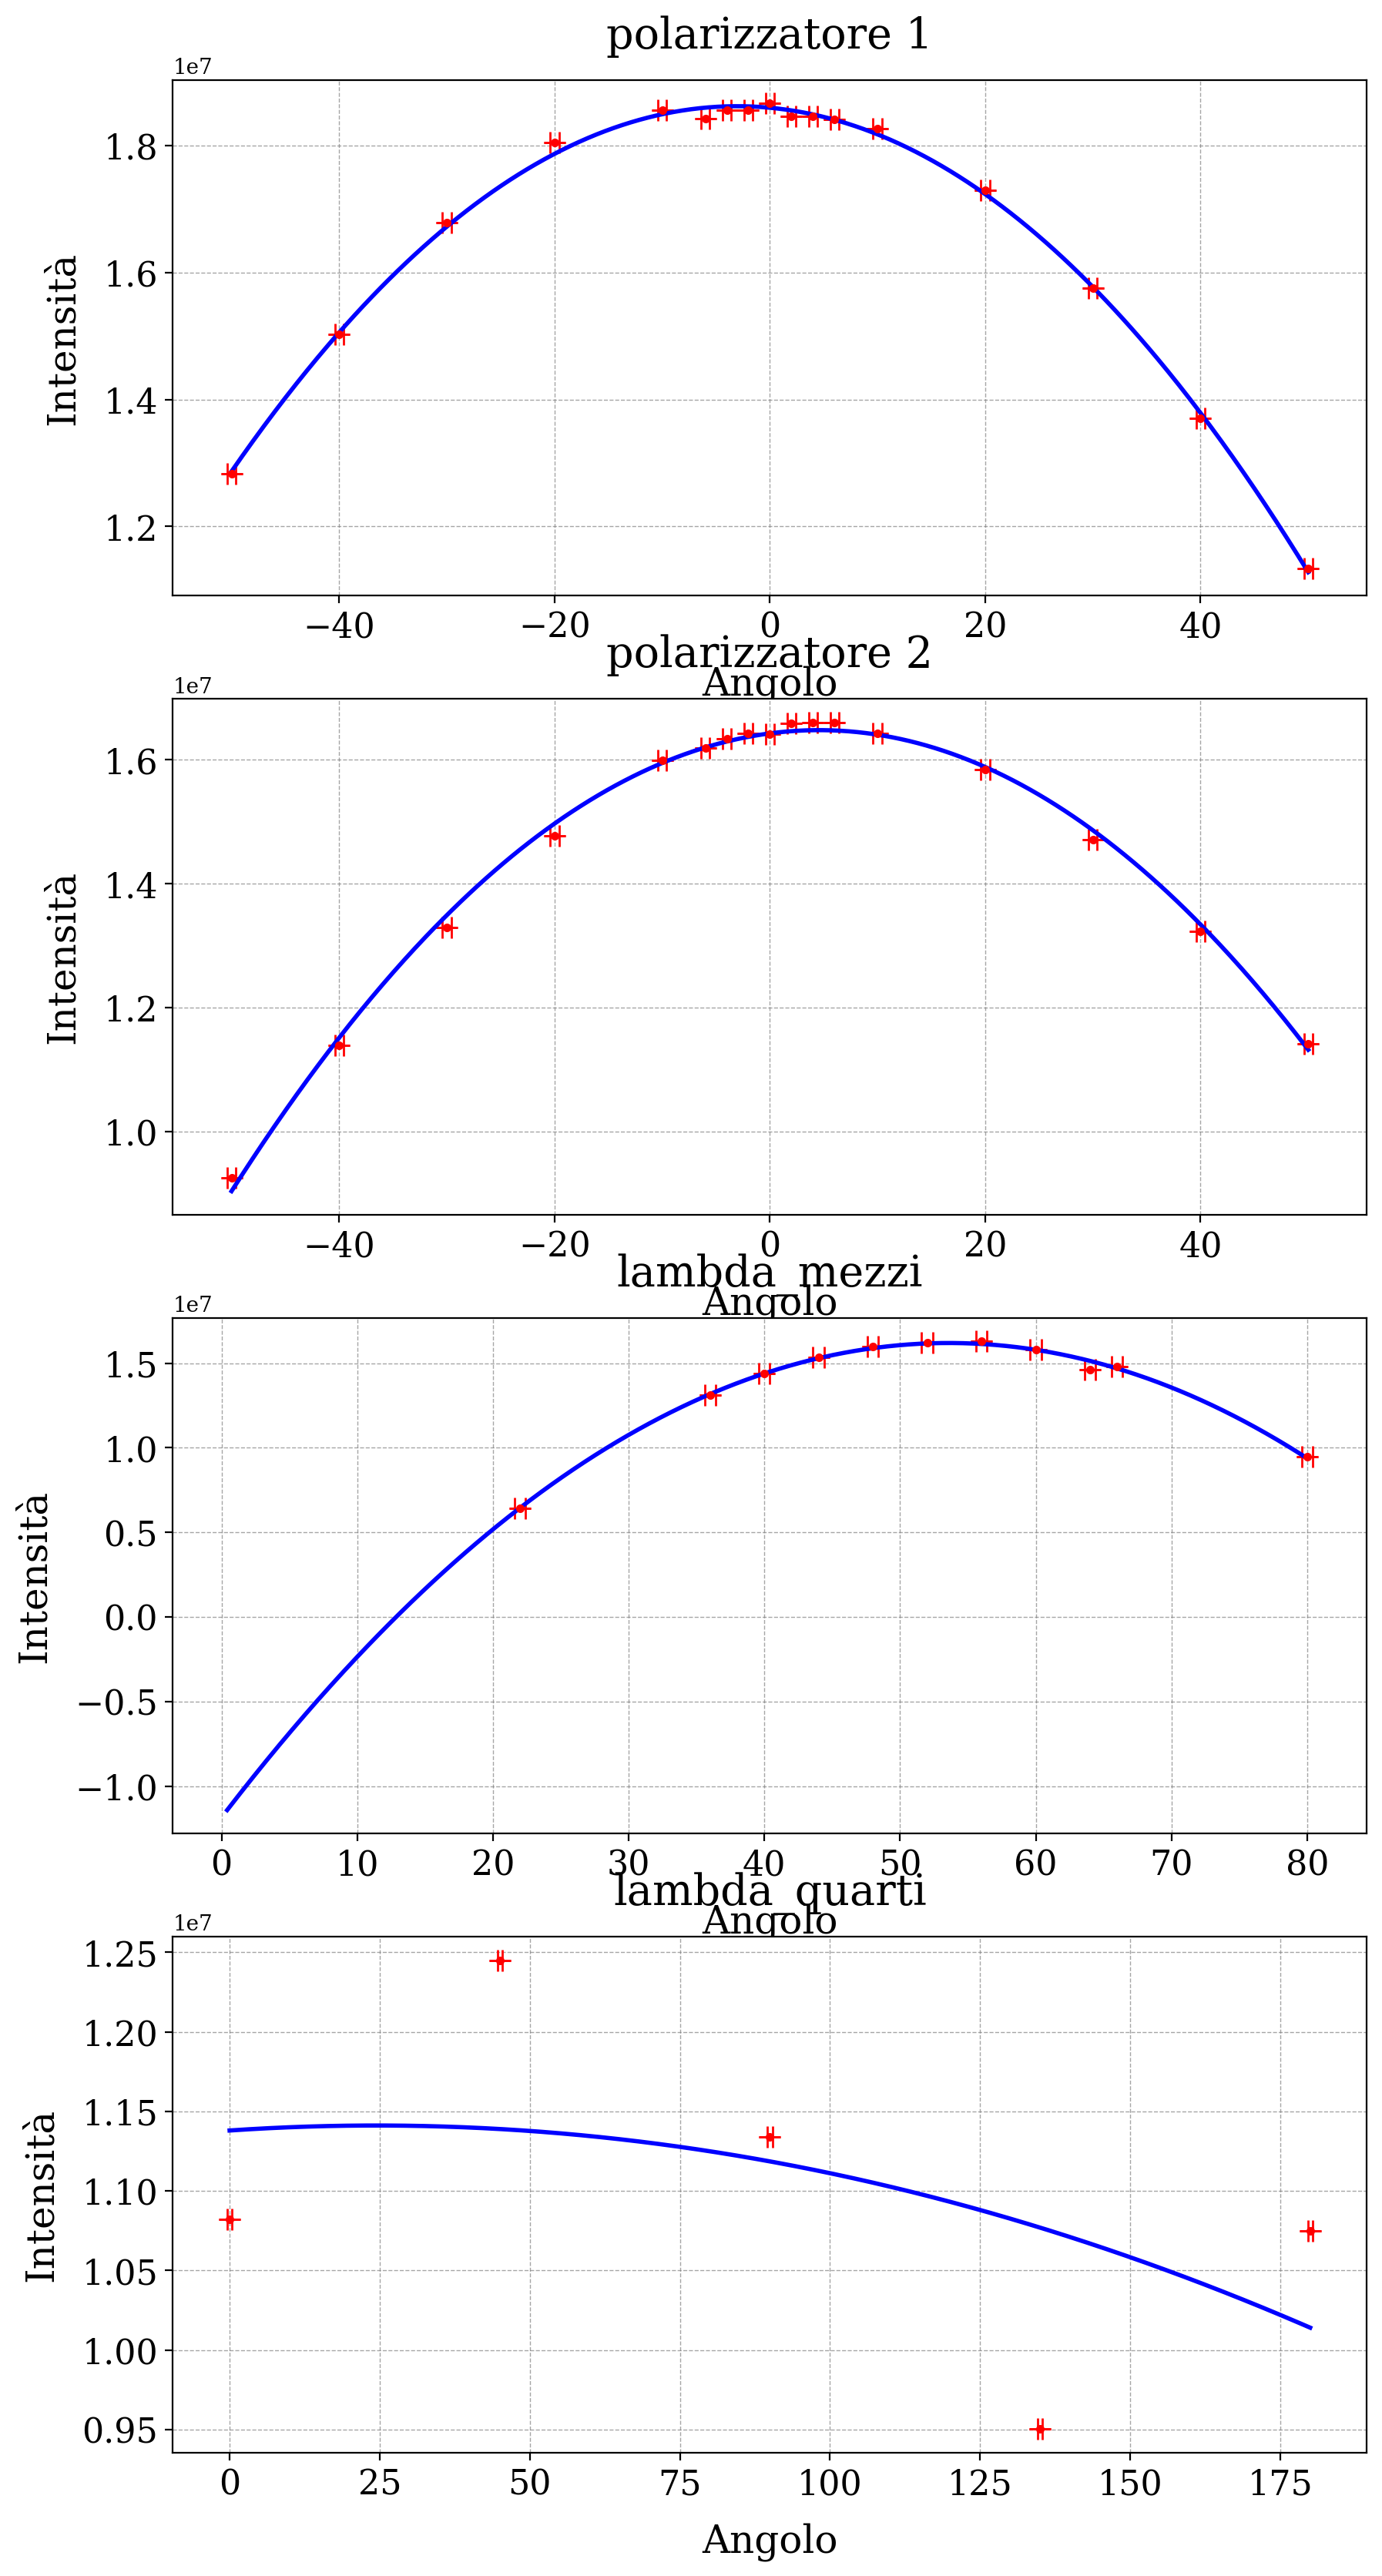

In [29]:
polarizzatori = {"polarizzatore 1" : data["punto9"],
        "polarizzatore 2": data["punto12"],
        "lambda_mezzi" : data["lambdamezzi"],
        "lambda_quarti" : data["lambdaquarti"]}
fig,axes = plt.subplots(4, 1, figsize=(10, 4*5))

for i,(titolo,dati) in enumerate(polarizzatori.items()):

    ax = axes[i]

    # Dati
    xdata = [dati["angolo"], np.full_like(dati["angolo"], 2/np.sqrt(24))]
    ydata = [dati["intensita"], np.full_like(dati["intensita"], 1/np.sqrt(12))]

    # Grafico dei dati
    gf.parametri_grafico(ax,titolo,xlabel="Angolo",ylabel="Intensità")
    ax.errorbar(xdata[0], ydata[0], xerr=xdata[1], yerr=ydata[1], color="red", fmt=".", **gf.default_error_params())

    # Modello parabolico con fit Chi Quadro
    def chi2(B, x, y, sy):
        (a, b, c) = B
        return np.sum(((y - (a*x**2 + b*x + c)) / sy) ** 2)
    from scipy.optimize import minimize
    x = xdata[0]
    y = ydata[0]
    sy = ydata[1]
    B0 = [-1000.0, 0.0, 1.0]
    res = minimize(chi2, B0, args=(x, y, sy))
    anal = [[res.x[0], np.sqrt(abs(res.hess_inv[0][0]))],
            [res.x[1], np.sqrt(abs(res.hess_inv[1][1]))],
            [res.x[2], np.sqrt(abs(res.hess_inv[2][2]))]]

    print(f"Fit {titolo}")
    print(f"\ta = {gf.formatta_errore(anal[0][0],anal[0][1],txt=True)}")
    print(f"\tb = {gf.formatta_errore(anal[1][0],anal[1][1],txt=True)}")
    print(f"\tc = {gf.formatta_errore(anal[2][0],anal[2][1],txt=True)}\n")

    # Plot fit
    def parabola(B, x):
        (a, b, c) = B
        return a*x**2 + b*x + c
    x = np.linspace(np.min(xdata), np.max(xdata), 500)
    y = parabola([anal[0][0], anal[1][0], anal[2][0]], x)
    ax.plot(x, y, color="blue")

    del xdata,ydata,x,y